# Investigating parameters effects on Sensitivity of the OGGM Mass Balance and Runoff Models

In this notebook we will explore the sensitivity of OGGM's mass-balance and runoff models using SAFE. We will focus on the three parameters: melt factor, precipitation factor and temperature bias.

We will start by applying one-at-a-time sensitivity analysis to get a feel for how much each parameter affects the model and output. We will then consider the uncertainty of these sensitivities and work to quantify them.

## Sensitivity Analysis with the OGGM Mass Balance Model

We will apply sensitivity analysis in the following order to investigate our model behaviour:

1. **One-at-a-time**: We will apply one-at-a-time analysis , in which we change one parameter at a time and see how the mass balance changes in accordance. To show this, we will plot an interactive mass balance time series with toggles, where the parameter values can be changed within their default boundaries.
2. **Global sensitivity analysis**: Here we will use AAT sampling to randomly sample a combination of the 3 parameters and investigate the sensitivity in the following ways
    a. Qualitative - scatter plots
    b. Quantitative - RSA and bootstrapping

This will be applied first to the mass balance model in the OGGM, and then to the runoff model in the OGGM.

First we install the packages we require from both OGGM and SAFE.

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import scipy.stats as st
import pandas as pd

from oggm import cfg, workflow, utils
from oggm.core import flowline, sensitivity
from oggm import tasks
from oggm.core.massbalance import MultipleFlowlineMassBalance

# Install python package for interactive visualisation and import required functions:
%pip install -q ipywidgets
from ipywidgets import interact

# Install SAFE package and import required functions
%pip install SAFEpython

import safepython.PAWN as PAWN # Module to calculate PAWN sensitivity indices
from safepython.sampling import AAT_sampling # Functions to perform the input sampling
from safepython.util import aggregate_boot # Functions to perform bootstrapping
import safepython.plot_functions as pf

from oggm.core.sensitivity import hydro_output_metric_calculator, run_with_runoff_for_sa, runoff_execution, mean_diff, parameter_bounding, spinup_area_volume

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


We start from a well known glacier in the Austrian Alps, Hintereisferner. But you can choose any other glacier, e.g. from [this list](https://github.com/OGGM/oggm-sample-data/blob/master/wgms/rgi_wgms_links_20220112.csv). We will load in the glacier directories and ensure our configuration is as required for our runs.

In [2]:
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = "/mnt/c/Users/yg25019/Documents/sensitivity_output"
cfg.PARAMS['border'] = 10
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['min_ice_thick_for_length'] = 1  # a glacier is when ice thicker than 1m

# Hintereisferner
rgi_id = 'RGI60-11.00897'

# We pick the elevation-bands glaciers because they run a bit faster - but they create more step changes in the area outputs
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'
gdir_hef = workflow.init_glacier_directories([rgi_id], from_prepro_level=4, prepro_border=160, prepro_base_url=base_url)[0]

# Get the observed mass balance and set up dataframe
mbdf = gdir_hef.get_ref_mb_data().loc[1979:] # WGMS data for HEF
mbdf['in_situ_mb'] = gdir_hef.get_ref_mb_data().loc[1979:]['ANNUAL_BALANCE'] # In-situ mass balance for comparison

# Hydrological model workflow steps before running with hydro
cfg.PARAMS['evolution_model'] = 'FluxBased'
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['error_when_glacier_reaches_boundaries'] = False

cfg.PARAMS['use_multiprocessing'] = True  # To speed up sensitivity analysis runs
cfg.PARAMS['mp_processes'] = os.cpu_count()  # Use all available cores

2026-03-04 09:48:38: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2026-03-04 09:48:38: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2026-03-04 09:48:38: oggm.cfg: Multiprocessing: using all available processors (N=22)
2026-03-04 09:48:38: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2026-03-04 09:48:38: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2026-03-04 09:48:38: oggm.cfg: PARAMS['min_ice_thick_for_length'] changed from `0.0` to `1`.
2026-03-04 09:48:38: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2026-03-04 09:48:38: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
2026-03-04 09:48:39: oggm.cfg: PARAMS['evolution_model'] changed from `SemiImplicit` to `FluxBased`.
2026-03-04 09:48:39: oggm.cfg: PARAMS['error_when_glacier_reaches_boundaries'] changed from `True` to `False`.
2026-03-04 09:48:39: oggm.cfg: Multiprocessing switched 

# Step 1 - The OGGM Runner, to produce runoff simulations

We have loaded all required packages, so now we need to create a runner for the OGGM. To do this, we will set the 3 mass balance parameters to some tentative values, run the model and plot the resulting runoff timeseries. We can then change the parameter values one-at-a-time and look at how this changes the model predictions.

This runner will produce a timeseries for the runoff.

The method will use run_with_hydro to create the hydrological data required to calculate the runoff in the OGGM.

The below method calculates the output metrics we will be using to understand the output of our hydrological simulations and our runoff timeseries. We currently do not have any observed data and so we are unsure of the values to expect, but we can still look into the mean and standard deviation, and use these in our sensitivity analysis.

Using the mean and standard deviation can give us a good picture of the data we have generated.

## Taking samples and producing the runoff in the OGGM

In [13]:
X_labels = ['melt_f', 'prcp_fac', 'temp_bias']
M = len(X_labels)

# gdir_hef.settings['error_when_glacier_reaches_boundaries'] = False # TODO- When more realistic, I assume we will not need this? 
distr_fun = st.uniform # Uniform distribution for all parameters
x_min = np.array([1.5, 1.0, -3]) # Minimum values for each parameter
x_max = np.array([7.0, 5.0, 3]) # Maximum values for each parameter

distr_par = [np.nan] * M
for i in range(M):
    distr_par[i] = [x_min[i], x_max[i] - x_min[i]]
    
samp_strat = 'lhs' 

N = 1000 # Number of samples

    Note: Will only need to run this once! Once it has run, the CSVs with the outputs will be saved

In [14]:
from oggm.core.sensitivity import runoff_execution_full_spinup

X = AAT_sampling(samp_strat, M, distr_fun, distr_par, N) # Generate the samples

area_volume_df = runoff_execution_full_spinup(fun_test = spinup_area_volume, 
                 X = X, # All samples
                 gdir = gdir_hef, # Hinteresfirner Glacier directory
                 years =range(1979, 2020), # years
                 init_model_yr = 1901, # Simulation start year - needs to be early enough to allow for spinup before the period we are interested in
                 ys =1901, # Start of the simulation
                 min_ys = 1901, # Minimum start year
                 ref_area_yr = 2004, # Reference area year - needs to be a year for which we have observed area data for the glacier, so we can use this to constrain the modelled glacier area during the spinup period
                 spinup_period = 21, # Spinup period in years (we are cutting this off, once the glacier has reached an equilibrium state, but this can be changed to a different period if desired)
                 csv_filepath = 'runoff_output.csv',
                 params_csv_filepath='params.csv',
                 run_task = tasks.run_from_climate_data,
                 mb_model_method = MultipleFlowlineMassBalance) # 50s, how to verify if we are running in parallel or not? Message is currently wrong??, it says I am iterating over 50 glaciers rather than 50 samples.

2026-03-04 09:51:00: oggm.cfg: PARAMS['continue_on_error'] changed from `False` to `True`.
2026-03-04 09:51:00: oggm.workflow: Execute entity tasks [spinup_area_volume] on 1000 glaciers
2026-03-04 09:51:03: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-03-04 09:51:03: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-03-04 09:51:03: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory date. This may indicate some problem in your workflow. Consider using `fixed_geometry_spinup_yr` for example.
2026-03-04 09:51:03: oggm.core.flowline: You are attempting to run_with_climate_data at dates prior to the RGI inventory 

<class 'list'> 1000


## Plot Area and Volume for the full period

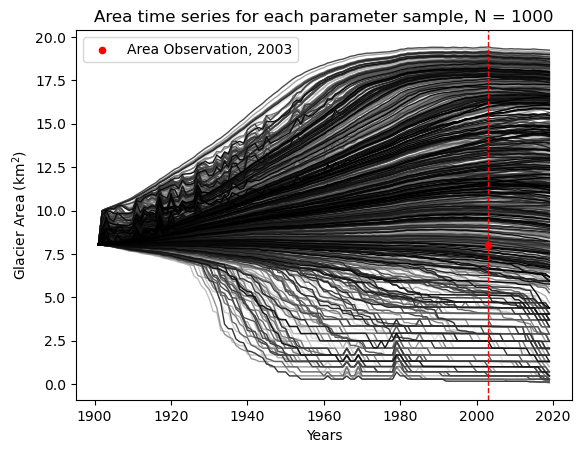

In [58]:
for i in range(N):
    full_area_km2 = area_volume_df[i]['area'] / 1e6

    # fade from black (0) → light grey (0.8)
    fade = (i / (N - 1)) 
    grey = fade * 0.8

    plt.plot(range(1901,2020), full_area_km2, color=plt.cm.Greys(i / (N-1)), linewidth=1)

plt.scatter(gdir_hef.rgi_date, gdir_hef.rgi_area_km2, color='r', s=20, zorder=999, label='Area Observation, 2003')
plt.axvline(x = gdir_hef.rgi_date, color = 'r', linestyle='--', linewidth=1)
plt.title('Area time series for each parameter sample, N = %d' % N)

plt.xlabel('Years'), plt.ylabel('Glacier Area (km$^2$)')
plt.legend()

plt.show()

Text(0.5, 1.0, 'Volume of the Glacier in the spinup period')

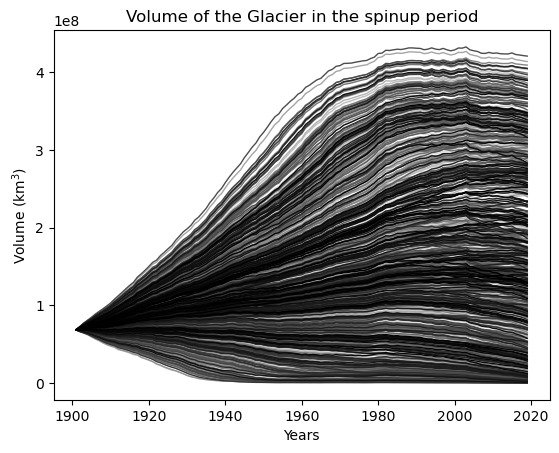

In [46]:
for i in range(N):
    full_volume_km3 = area_volume_df[i]['volume'] / 9

    # fade from black (0) → light grey (0.8)
    fade = (i / (N - 1)) 
    grey = fade * 0.8

    plt.plot(range(1901, 2020), full_volume_km3, color=plt.cm.Greys(i / (N-1)), linewidth=1)

plt.xlabel('Years'), plt.ylabel('Volume (km$^3$)')
plt.title('Volume of the Glacier in the spinup period')